In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


ticker = 'AAPL'
data = yf.download(ticker, period='10000d', interval='1d')
df = data[['Close', 'Volume']].dropna()



scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)


look_back = 60
X, y = [], []
for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)


[*********************100%***********************]  1 of 1 completed


In [ ]:
def add_indicators(df):
    df['MA_10'] = df['Close'].rolling(window=10).mean()
    df['MA_50'] = df['Close'].rolling(window=50).mean()
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    df = df.dropna()
    return df

df = add_indicators(data)


In [ ]:
model = Sequential()
num_features = 2
model.add(LSTM(128, return_sequences=True, input_shape=(look_back, num_features)))
model.add(LSTM(64))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))


Epoch 1/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 39s 140ms/step - loss: 1.4301e-04 - val_loss: 4.8945e-04
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 39s 133ms/step - loss: 2.4898e-06 - val_loss: 5.8215e-04
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 43s 143ms/step - loss: 2.6086e-06 - val_loss: 0.0014
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 33s 131ms/step - loss: 2.7847e-06 - val_loss: 4.0030e-04
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - loss: 1.8762e-06 - val_loss: 5.3649e-04
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 38s 125ms/step - loss: 2.1368e-06 - val_loss: 4.7143e-04
Epoch 7/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 39s 118ms/step - loss: 2.6454e-06 - val_loss: 3.9860e-04
Epoch 8/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 30s 120ms/step - loss: 1.9092e-06 - val_loss: 4.3679e-04
Epoch 9/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 44s 132ms/step - loss: 1.3392e-06 - val_loss: 7.0116e-04
Epoch 10/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - loss: 1.4791e-06 - val_loss: 2.9260e-04
Epoch 11/30
249/249 ━━━━━━━━━━━━━

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import math


predicted = model.predict(X_test)


rmse = math.sqrt(mean_squared_error(y_test, predicted))
mae = mean_absolute_error(y_test, predicted)
r2 = r2_score(y_test, predicted)


print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")



63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step
Root Mean Squared Error (RMSE): 0.0111
Mean Absolute Error (MAE): 0.0075
R² Score: 0.9980


In [ ]:
from sklearn.metrics import mean_squared_error
import math

predicted = model.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, predicted))
print(f"RMSE: {rmse}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
RMSE: 0.011089951255266574


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


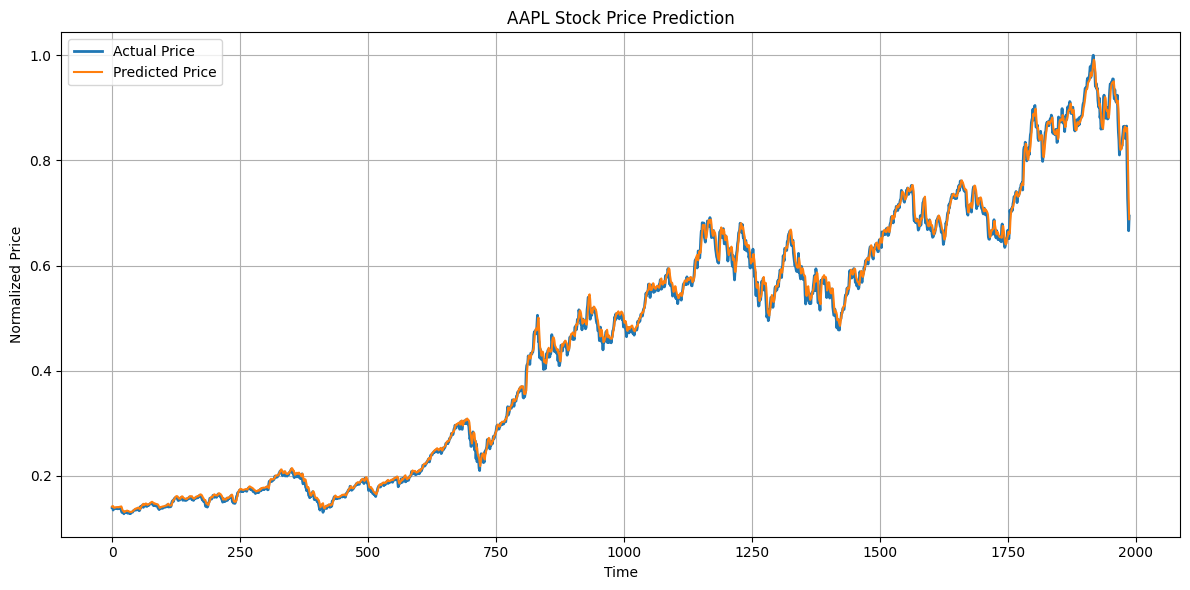

In [ ]:
import matplotlib.pyplot as plt


predicted = model.predict(X_test)


plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Price', linewidth=2)
plt.plot(predicted, label='Predicted Price')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd


df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()


<ipython-input-10-95f996343856>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA10'] = df['Close'].rolling(window=10).mean()
<ipython-input-10-95f996343856>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA50'] = df['Close'].rolling(window=50).mean()


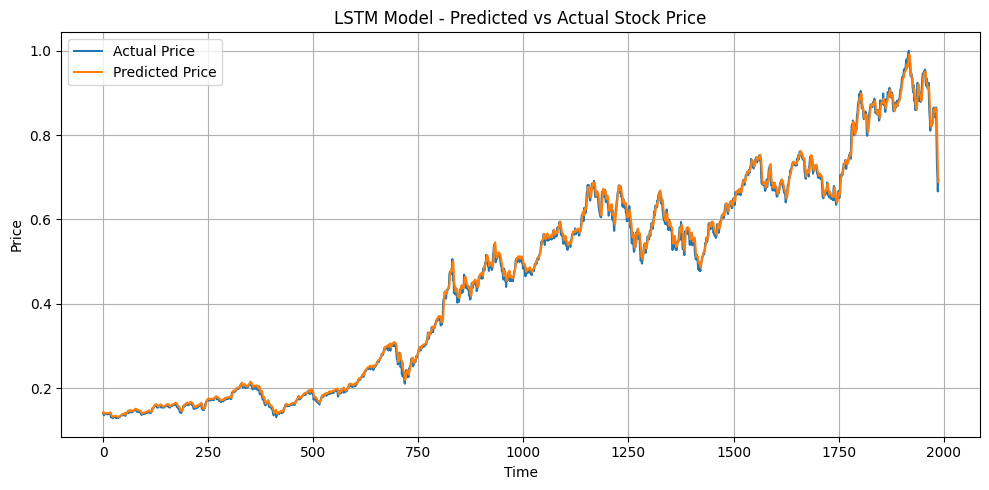

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Actual Price')
plt.plot(predicted, label='Predicted Price')
plt.title('LSTM Model - Predicted vs Actual Stock Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('figures/predictions_vs_actual.png', dpi=300)
plt.show()
plt.close()


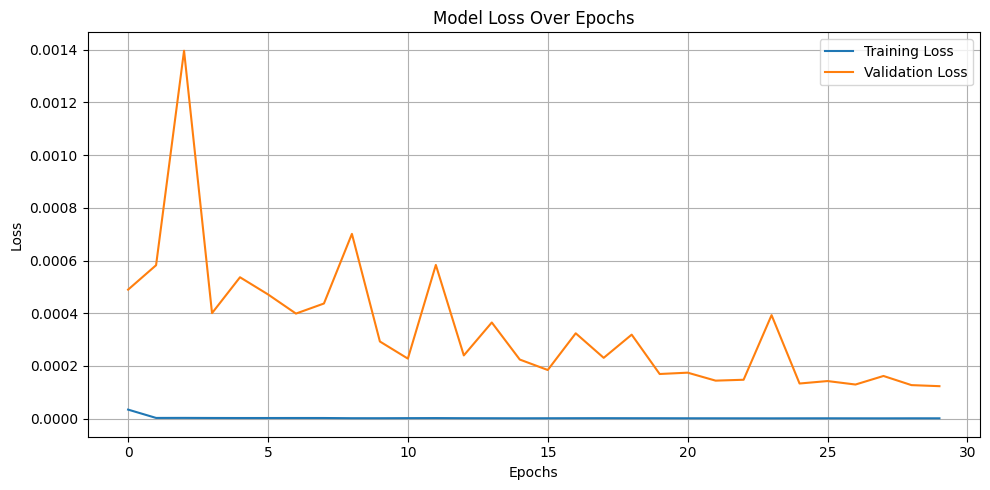

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('figures/loss_curve.png', dpi=300)
plt.show()
plt.close()

In [ ]:
import yfinance as yf
import datetime
import numpy as np
import pandas as pd

def predict_today(model, scaler, symbol='AAPL', history_days=60):

    end = datetime.datetime.now()
    start = end - datetime.timedelta(days=history_days*2)
    data = yf.download(symbol, start=start, end=end)


    data = data[-history_days:]

    features = ['Close', 'Volume']
    scaled_data = scaler.transform(data[features])

    X_input = np.array(scaled_data).reshape(1, history_days, scaler.n_features_in_)

    y_pred_scaled = model.predict(X_input)


    dummy_pred = np.zeros((1, scaler.n_features_in_))
    dummy_pred[0, 0] = y_pred_scaled
    predicted_price = scaler.inverse_transform(dummy_pred)[0, 0]


    today = data.index[-1].strftime("%Y-%m-%d")
    print(f"📈 Predicted closing price for {symbol} on {today}: ${predicted_price:.2f}")
    return predicted_price

In [ ]:
predict_today(model, scaler, symbol='AAPL')


[*********************100%***********************]  1 of 1 completed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
📈 Predicted closing price for AAPL on 2025-04-09: $175.56



<ipython-input-13-807c68aab432>:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dummy_pred[0, 0] = y_pred_scaled


np.float64(175.5567911151195)